# COMP 9130 | SafeSpace AI Content Moderation
**Author:** Binger Yu  
**Mini Project 9 — Part 2: Traditional ML Baseline**

This notebook builds a TF-IDF + classifier pipeline as the baseline that the transformer (Part 3) must beat.

Steps:
1. Load preprocessed splits from Part 1
2. TF-IDF vectorisation
3. Train Logistic Regression (primary), SVM, and Random Forest
4. Hyperparameter tuning
5. Evaluation: accuracy, per-class precision/recall/F1, confusion matrix
6. Confidence / threshold analysis
7. TF-IDF feature importance
8. Baseline summary table

## 0. Setup
> **Colab persistence:** Outputs are written to Google Drive. Mount Drive and set `PROJECT_ROOT` to match the path used in `01_exploration_colab.ipynb`.

In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install -q pandas numpy matplotlib seaborn scikit-learn

In [2]:
# ── Mount Google Drive (run once per session) ─────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# ── Project-wide configuration ────────────────────────────────────────────────
# Must match the PROJECT_ROOT used in 01_exploration_colab.ipynb
PROJECT_ROOT = '/content/drive/My Drive/Colab Notebooks/mini-project-9'

import os
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
FIG_DIR  = os.path.join(PROJECT_ROOT, 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR,  exist_ok=True)

RANDOM_SEED = 42

LABEL_MAP    = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}
LABEL_COLORS = {0: '#d62728',     1: '#ff7f0e',            2: '#2ca02c'}
CLASS_NAMES  = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]   # derived — no duplication

print(f'DATA_DIR : {DATA_DIR}')
print(f'FIG_DIR  : {FIG_DIR}')

DATA_DIR : /content/drive/My Drive/Colab Notebooks/mini-project-9/data
FIG_DIR  : /content/drive/My Drive/Colab Notebooks/mini-project-9/figures


In [7]:
# ── Standard imports ──────────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)

warnings.filterwarnings('ignore')
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## 1. Load Preprocessed Splits
> Splits were created and saved in `01_exploration_colab.ipynb` with stratified 70/15/15 splitting.

In [8]:
# ── Load train / val / test CSVs saved from Part 1 ───────────────────────────
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'val.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

X_train, y_train = train_df['text'].values, train_df['label'].values
X_val,   y_val   = val_df['text'].values,   val_df['label'].values
X_test,  y_test  = test_df['text'].values,  test_df['label'].values

# Combine train + val for final model training (standard practice)
X_trainval = np.concatenate([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

n_classes = len(np.unique(y_train))   # derived — not hardcoded

print(f'Train : {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')
print(f'TrainVal (combined): {len(X_trainval):,}')
print(f'\nClass distribution in train:')
for cls_id, count in zip(*np.unique(y_train, return_counts=True)):
    print(f'  Class {cls_id} ({LABEL_MAP[int(cls_id)]:20s}): {count:5,} ({count/len(y_train)*100:.1f}%)')

Train : 17,346  |  Val: 3,717  |  Test: 3,718
TrainVal (combined): 21,063

Class distribution in train:
  Class 0 (Hate Speech         ): 1,001 (5.8%)
  Class 1 (Offensive Language  ): 13,432 (77.4%)
  Class 2 (Neither             ): 2,913 (16.8%)


## 2. TF-IDF + Logistic Regression Pipeline

**Why Logistic Regression?** Fast, interpretable, handles high-dimensional sparse features (TF-IDF) well, and supports `class_weight='balanced'` to address class imbalance. It is a strong baseline for text classification.

**Why TF-IDF?** Captures word importance relative to document frequency — downweighting common words and upweighting rare discriminative ones. N-gram features (bigrams) capture short phrases.

In [9]:
# ── TF-IDF pipeline configuration ─────────────────────────────────────────────
# These defaults are overridden by grid search; centralised here so they are
# easy to change without hunting through the notebook.
TFIDF_DEFAULTS = dict(
    ngram_range   = (1, 2),
    sublinear_tf  = True,
    min_df        = 3,
    strip_accents = 'unicode',
    analyzer      = 'word',
)
LR_DEFAULTS = dict(
    class_weight = 'balanced',
    max_iter     = 1000,
    solver       = 'lbfgs',
    multi_class  = 'multinomial',
    random_state = RANDOM_SEED,
)

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50_000, **TFIDF_DEFAULTS)),
    ('clf',   LogisticRegression(**LR_DEFAULTS))
])

print('Pipeline created:')
print(f'  TF-IDF : {TFIDF_DEFAULTS}')
print(f'  LogReg : {LR_DEFAULTS}')

Pipeline created:
  TF-IDF : {'ngram_range': (1, 2), 'sublinear_tf': True, 'min_df': 3, 'strip_accents': 'unicode', 'analyzer': 'word'}
  LogReg : {'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'lbfgs', 'multi_class': 'multinomial', 'random_state': 42}


## 3. Hyperparameter Tuning

We tune two key hyperparameters:
- `tfidf__max_features`: caps vocabulary size — too large → noise, too small → loss of signal.
- `clf__C`: logistic regression regularisation strength — smaller C = more regularisation.

We use 5-fold cross-validation on the training set, optimising **macro F1** (treats all classes equally — important for the rare hate speech class).

In [10]:
# ── Grid search over key hyperparameters ──────────────────────────────────────
param_grid = {
    'tfidf__max_features': [20_000, 50_000, 100_000],
    'clf__C':              [0.1, 1.0, 10.0],
}

CV_FOLDS = 5
grid_search = GridSearchCV(
    lr_pipeline,
    param_grid,
    cv=CV_FOLDS,
    scoring='f1_macro',   # macro F1 — equal weight to all classes incl. hate speech
    n_jobs=-1,
    verbose=1
)

print(f'Running {CV_FOLDS}-fold cross-validation grid search...')
print('Scoring: macro F1 (treats all classes equally)\n')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print(f'\n  ✅ Best parameters : {best_params}')
print(f'     Best CV macro F1 : {grid_search.best_score_:.4f}')

Running 5-fold cross-validation grid search...
Scoring: macro F1 (treats all classes equally)

Fitting 5 folds for each of 9 candidates, totalling 45 fits

  ✅ Best parameters : {'clf__C': 1.0, 'tfidf__max_features': 20000}
     Best CV macro F1 : 0.7284


Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/figures/grid_search_heatmap.png


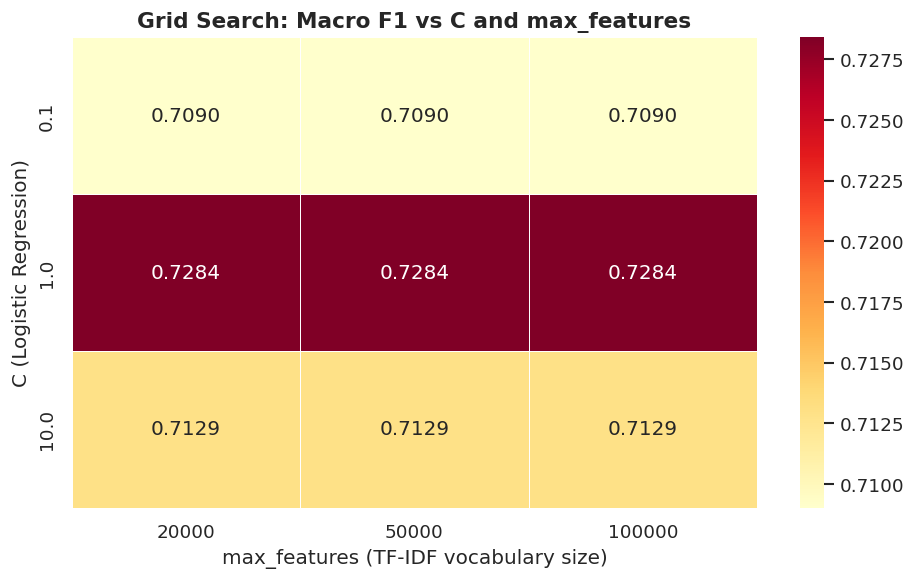


Best configuration: C=1.0, max_features=20000


In [11]:
# ── Visualise grid search results ─────────────────────────────────────────────
results = pd.DataFrame(grid_search.cv_results_)
pivot   = results.pivot_table(
    values  = 'mean_test_score',
    index   = 'param_clf__C',
    columns = 'param_tfidf__max_features'
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Grid Search: Macro F1 vs C and max_features', fontsize=13, fontweight='bold')
ax.set_xlabel('max_features (TF-IDF vocabulary size)')
ax.set_ylabel('C (Logistic Regression)')
plt.tight_layout()

save_path = os.path.join(FIG_DIR, 'grid_search_heatmap.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

print(f'\nBest configuration: C={best_params["clf__C"]}, '
      f'max_features={best_params["tfidf__max_features"]}')

## 4. Train Final Logistic Regression Model
> Using the best hyperparameters found by grid search, trained on the full train+val set.

In [12]:
# ── Build and train final LR model on train+val ───────────────────────────────
final_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features = best_params['tfidf__max_features'],
        **TFIDF_DEFAULTS
    )),
    ('clf', LogisticRegression(
        C = best_params['clf__C'],
        **LR_DEFAULTS
    ))
])

final_lr.fit(X_trainval, y_trainval)

vocab_size = len(final_lr.named_steps['tfidf'].vocabulary_)
print(f'Final model trained on {len(X_trainval):,} samples (train + val).')
print(f'TF-IDF vocabulary size: {vocab_size:,}')

Final model trained on 21,063 samples (train + val).
TF-IDF vocabulary size: 18,425


## 5. Evaluate on Test Set

In [13]:
# ── Test set predictions and metrics ─────────────────────────────────────────
y_pred_lr = final_lr.predict(X_test)
y_prob_lr = final_lr.predict_proba(X_test)

acc_lr      = accuracy_score(y_test, y_pred_lr)
macro_f1_lr = f1_score(y_test, y_pred_lr, average='macro')
per_class_f1 = f1_score(y_test, y_pred_lr, average=None)

print('=' * 60)
print('LOGISTIC REGRESSION BASELINE — TEST SET RESULTS')
print('=' * 60)
print(f'\nOverall Accuracy : {acc_lr:.4f}')
print(f'Macro F1         : {macro_f1_lr:.4f}')
print(f'\nDetailed Classification Report:')
print(classification_report(y_test, y_pred_lr, target_names=CLASS_NAMES))
print('  ⚠ Note: Accuracy looks inflated due to the dominant Offensive class.')
print('    Macro F1 is the key metric — it penalises poor hate speech detection.')

LOGISTIC REGRESSION BASELINE — TEST SET RESULTS

Overall Accuracy : 0.8701
Macro F1         : 0.7301

Detailed Classification Report:
                    precision    recall  f1-score   support

       Hate Speech       0.34      0.54      0.41       214
Offensive Language       0.97      0.88      0.92      2879
           Neither       0.78      0.95      0.86       625

          accuracy                           0.87      3718
         macro avg       0.69      0.79      0.73      3718
      weighted avg       0.90      0.87      0.88      3718

  ⚠ Note: Accuracy looks inflated due to the dominant Offensive class.
    Macro F1 is the key metric — it penalises poor hate speech detection.


Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/figures/baseline_confusion_matrix.png


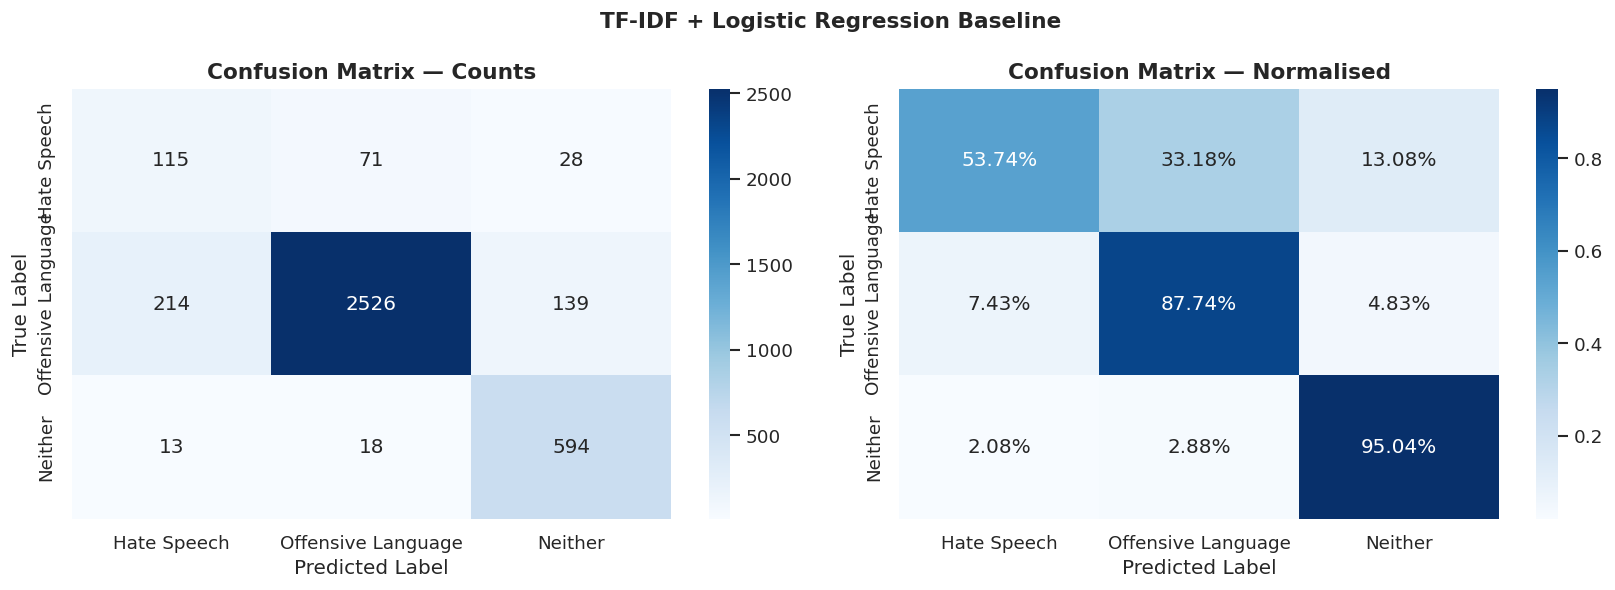

In [14]:
# ── Confusion matrices ────────────────────────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred_lr)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_kwargs = dict(xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')

sns.heatmap(cm,      annot=True, fmt='d',   ax=axes[0], **cm_kwargs)
sns.heatmap(cm_norm, annot=True, fmt='.2%', ax=axes[1], **cm_kwargs)

for ax, title in zip(axes, ['Counts', 'Normalised']):
    ax.set_ylabel('True Label',      fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')

plt.suptitle('TF-IDF + Logistic Regression Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(FIG_DIR, 'baseline_confusion_matrix.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

## 6. Comparison: LR vs SVM vs Random Forest
> We also train two alternative classifiers with the same TF-IDF features to validate our choice.

In [15]:
# ── Shared TF-IDF transform (fit on trainval, transform test) ─────────────────
tfidf_shared = TfidfVectorizer(
    max_features = best_params['tfidf__max_features'],
    **TFIDF_DEFAULTS
)
X_trainval_tfidf = tfidf_shared.fit_transform(X_trainval)
X_test_tfidf     = tfidf_shared.transform(X_test)

# ── Classifier definitions ────────────────────────────────────────────────────
classifiers = {
    'Logistic Regression': LogisticRegression(
        C=best_params['clf__C'], **LR_DEFAULTS
    ),
    'LinearSVC (SVM)': CalibratedClassifierCV(   # wraps SVC to get probabilities
        LinearSVC(C=1.0, class_weight='balanced',
                  max_iter=2000, random_state=RANDOM_SEED)
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=RANDOM_SEED, n_jobs=-1
    ),
}

# ── Evaluate all classifiers ──────────────────────────────────────────────────
comparison_results = []
for name, clf in classifiers.items():
    clf.fit(X_trainval_tfidf, y_trainval)
    preds    = clf.predict(X_test_tfidf)
    acc      = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average='macro')
    pcf1     = f1_score(y_test, preds, average=None)   # per-class F1
    row = {'Classifier': name, 'Accuracy': acc, 'Macro F1': macro_f1}
    row.update({f'F1 - {LABEL_MAP[i]}': pcf1[i] for i in range(n_classes)})
    comparison_results.append(row)
    print(f'  {name:28s}: Acc={acc:.4f}  MacroF1={macro_f1:.4f}  '
          f'HateF1={pcf1[0]:.4f}')

comparison_df = pd.DataFrame(comparison_results)
print('\nFull comparison table:')
print(comparison_df.to_string(index=False, float_format='{:.4f}'.format))

  Logistic Regression         : Acc=0.8701  MacroF1=0.7301  HateF1=0.4137
  LinearSVC (SVM)             : Acc=0.9024  MacroF1=0.6856  HateF1=0.2581
  Random Forest               : Acc=0.8905  MacroF1=0.6453  HateF1=0.1769

Full comparison table:
         Classifier  Accuracy  Macro F1  F1 - Hate Speech  F1 - Offensive Language  F1 - Neither
Logistic Regression    0.8701    0.7301            0.4137                   0.9195        0.8571
    LinearSVC (SVM)    0.9024    0.6856            0.2581                   0.9424        0.8562
      Random Forest    0.8905    0.6453            0.1769                   0.9351        0.8238


Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/figures/classifier_comparison.png


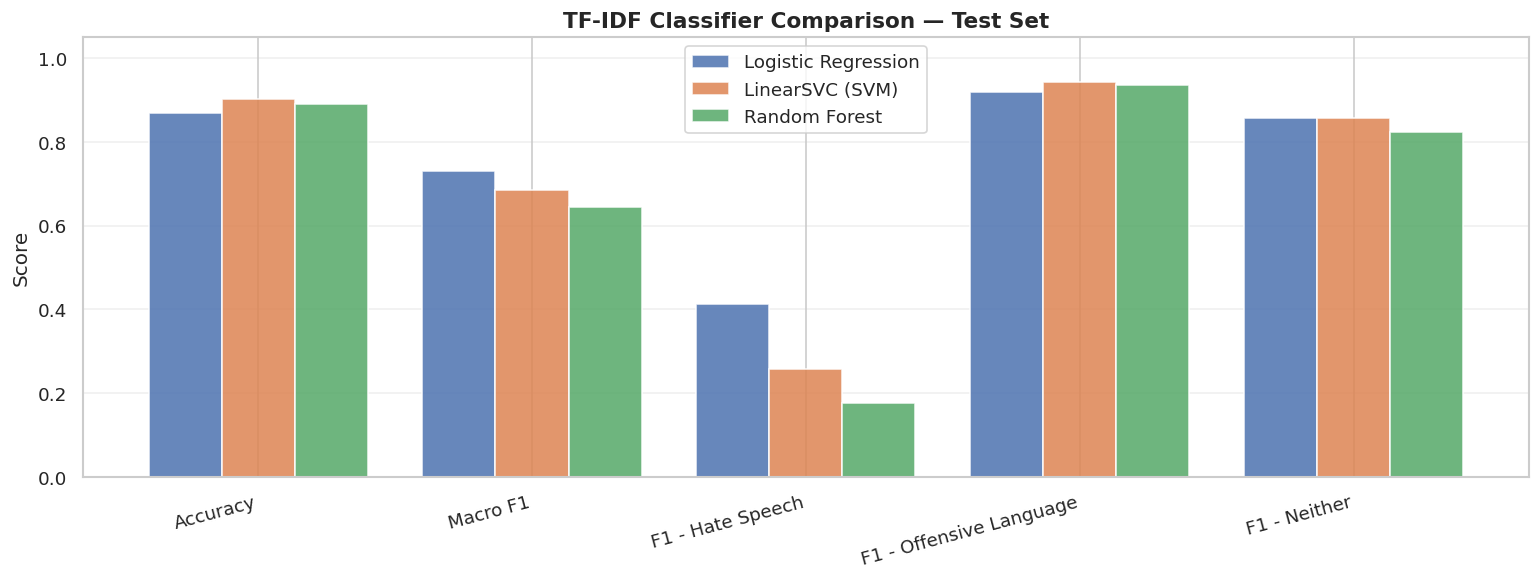

In [16]:
# ── Visualise classifier comparison ──────────────────────────────────────────
metric_cols  = [c for c in comparison_df.columns if c != 'Classifier']
n_classifiers = len(comparison_df)
x     = np.arange(len(metric_cols))
width = 0.8 / n_classifiers           # auto-scale bar width to number of classifiers
bar_colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (_, row) in enumerate(comparison_df.iterrows()):
    offset = (i - n_classifiers / 2 + 0.5) * width
    ax.bar(x + offset, [row[m] for m in metric_cols],
           width, label=row['Classifier'],
           color=bar_colors[i % len(bar_colors)], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metric_cols, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('TF-IDF Classifier Comparison — Test Set', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

save_path = os.path.join(FIG_DIR, 'classifier_comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

## 7. Confidence Threshold Analysis

In a production content moderation system, low-confidence predictions should be routed to human reviewers rather than acted upon automatically. This section explores the accuracy/coverage trade-off.

Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/figures/baseline_confidence_threshold.png


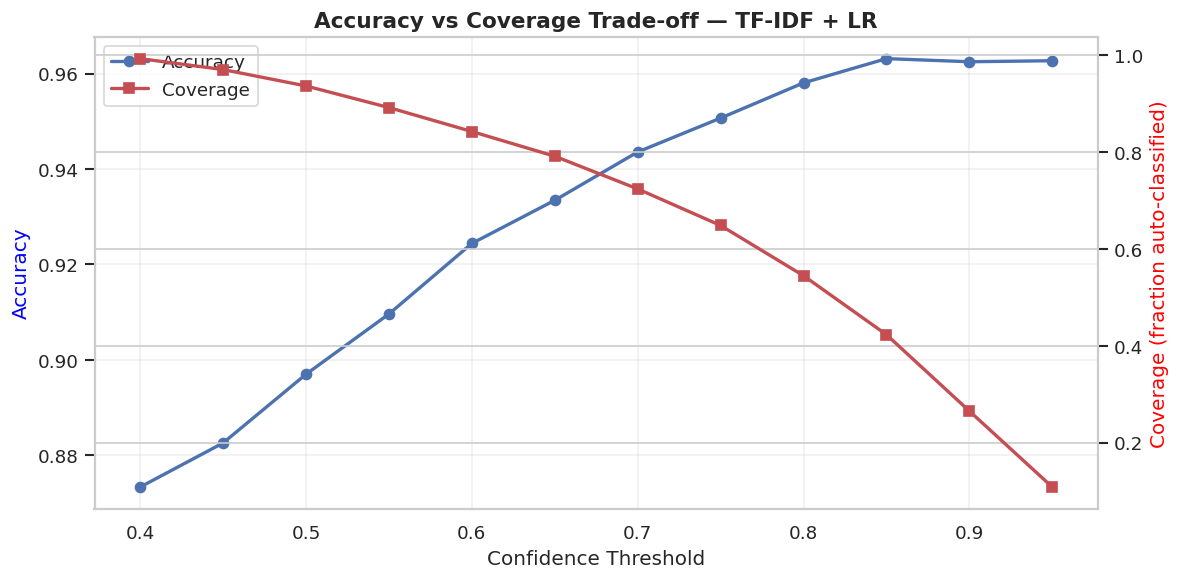


  Production Insight:
   High threshold → higher accuracy, but more posts sent to human review.
   This trade-off is central to Part 5 (Production Workflow Design).


In [17]:
# ── Accuracy vs Coverage at different confidence thresholds ───────────────────
THRESH_START = 0.40
THRESH_STOP  = 1.00
THRESH_STEP  = 0.05

pred_confidence = np.max(y_prob_lr, axis=1)
thresholds      = np.arange(THRESH_START, THRESH_STOP, THRESH_STEP)
accs, coverages = [], []

for thresh in thresholds:
    mask = pred_confidence >= thresh
    if mask.sum() > 0:
        accs.append(accuracy_score(y_test[mask], y_pred_lr[mask]))
        coverages.append(mask.sum() / len(mask))
    else:
        accs.append(np.nan)
        coverages.append(0.0)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(thresholds, accs,      'b-o', label='Accuracy', linewidth=2)
ax2.plot(thresholds, coverages, 'r-s', label='Coverage', linewidth=2)

ax1.set_xlabel('Confidence Threshold', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12, color='blue')
ax2.set_ylabel('Coverage (fraction auto-classified)', fontsize=12, color='red')
ax1.set_title('Accuracy vs Coverage Trade-off — TF-IDF + LR',
              fontsize=13, fontweight='bold')

lines  = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, fontsize=11)
ax1.grid(alpha=0.3)
plt.tight_layout()

save_path = os.path.join(FIG_DIR, 'baseline_confidence_threshold.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

print('\n  Production Insight:')
print('   High threshold → higher accuracy, but more posts sent to human review.')
print('   This trade-off is central to Part 5 (Production Workflow Design).')

## 8. TF-IDF Feature Importance

Logistic regression coefficients reveal which words are most predictive of each class — giving interpretability that the transformer cannot easily provide.

Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/figures/feature_importance.png


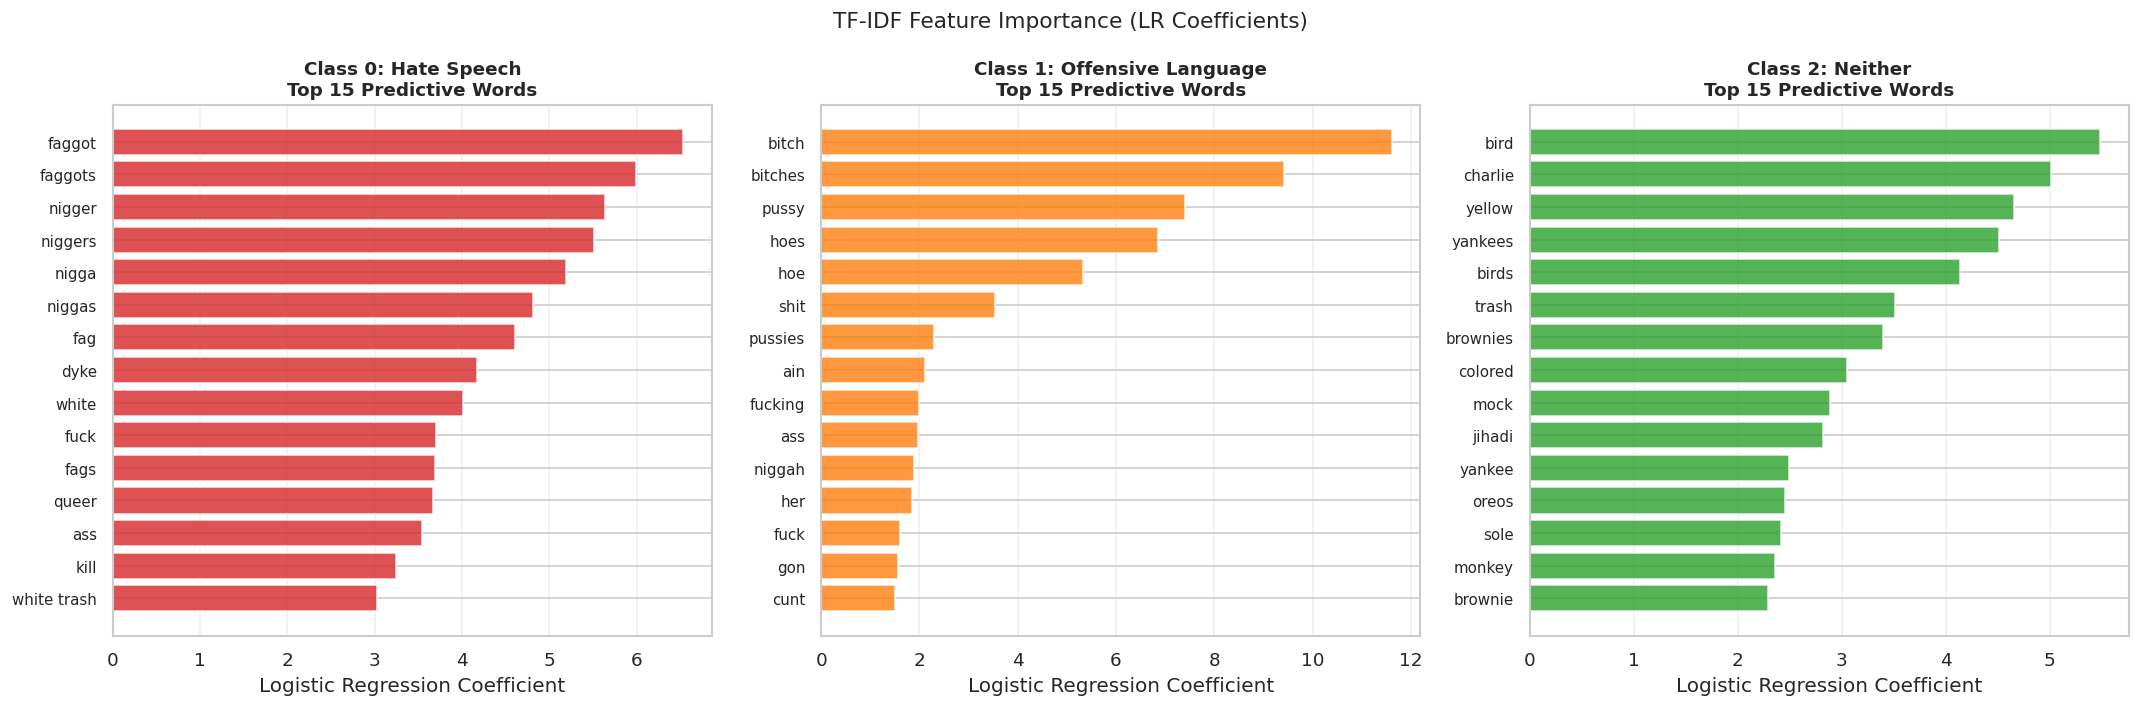


  ✏ Interpretability is a key advantage of TF-IDF + LR over deep models.
    You can directly explain WHY a tweet was flagged — important for auditing.


In [18]:
# ── Top TF-IDF features per class from LR coefficients ───────────────────────
N_TOP        = 15
feature_names = np.array(final_lr.named_steps['tfidf'].get_feature_names_out())
coefs         = final_lr.named_steps['clf'].coef_   # shape: (n_classes, n_features)

fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 6))

for cls_id in range(n_classes):
    top_idx   = np.argsort(coefs[cls_id])[-N_TOP:][::-1]
    top_words = feature_names[top_idx]
    top_coefs = coefs[cls_id][top_idx]

    axes[cls_id].barh(range(N_TOP), top_coefs[::-1],
                      color=LABEL_COLORS[cls_id], alpha=0.8)
    axes[cls_id].set_yticks(range(N_TOP))
    axes[cls_id].set_yticklabels(top_words[::-1], fontsize=9)
    axes[cls_id].set_xlabel('Logistic Regression Coefficient')
    axes[cls_id].set_title(
        f'Class {cls_id}: {LABEL_MAP[cls_id]}\nTop {N_TOP} Predictive Words',
        fontsize=11, fontweight='bold'
    )
    axes[cls_id].grid(axis='x', alpha=0.3)

plt.suptitle('TF-IDF Feature Importance (LR Coefficients)', fontsize=13)
plt.tight_layout()

save_path = os.path.join(FIG_DIR, 'feature_importance.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

print('\n  ✏ Interpretability is a key advantage of TF-IDF + LR over deep models.')
print('    You can directly explain WHY a tweet was flagged — important for auditing.')

## 9. Baseline Summary
> This table will be used in the report for the transformer comparison.

In [19]:
# ── Summary — all values derived, none hardcoded ──────────────────────────────
print('=' * 65)
print('BASELINE SUMMARY — TF-IDF + Logistic Regression')
print('=' * 65)
print(f'  Best hyperparameters : C={best_params["clf__C"]}, '
      f'max_features={best_params["tfidf__max_features"]}')
print(f'  N-gram range         : {TFIDF_DEFAULTS["ngram_range"]}  — unigrams + bigrams')
print(f'  Class weighting      : balanced (inverse frequency)')
print(f'  Vocabulary size      : {vocab_size:,}')
print()
print(f'  Accuracy             : {acc_lr:.4f}')
print(f'  Macro F1             : {macro_f1_lr:.4f}')
for cls_id in range(n_classes):
    marker = '  ← most critical class' if cls_id == 0 else ''
    print(f'  F1 — {LABEL_MAP[cls_id]:20s}: {per_class_f1[cls_id]:.4f}{marker}')
print()
print('  ⚠  This is the BASELINE. The transformer (Part 3) must beat these numbers')
print('     to justify its additional complexity, training time, and cost.')
print()
print('  Key Limitation: TF-IDF treats each word independently (bag-of-words).')
print('  It cannot capture word order, context, or sarcasm.')
print('  Example failure: "I love how everyone thinks he is normal" —')
print('  TF-IDF sees "love" + "normal" → probably Neither.')
print('  DistilBERT reads the full sequence and may catch the sarcasm.')

BASELINE SUMMARY — TF-IDF + Logistic Regression
  Best hyperparameters : C=1.0, max_features=20000
  N-gram range         : (1, 2)  — unigrams + bigrams
  Class weighting      : balanced (inverse frequency)
  Vocabulary size      : 18,425

  Accuracy             : 0.8701
  Macro F1             : 0.7301
  F1 — Hate Speech         : 0.4137  ← most critical class
  F1 — Offensive Language  : 0.9195
  F1 — Neither             : 0.8571

  ⚠  This is the BASELINE. The transformer (Part 3) must beat these numbers
     to justify its additional complexity, training time, and cost.

  Key Limitation: TF-IDF treats each word independently (bag-of-words).
  It cannot capture word order, context, or sarcasm.
  Example failure: "I love how everyone thinks he is normal" —
  TF-IDF sees "love" + "normal" → probably Neither.
  DistilBERT reads the full sequence and may catch the sarcasm.


In [20]:
# ── Save baseline predictions for use in Part 4 comparison ───────────────────
prob_cols = {f'prob_{LABEL_MAP[i].lower().replace(" ", "_")}': y_prob_lr[:, i]
             for i in range(n_classes)}

preds_df = pd.DataFrame({'y_true': y_test, 'y_pred_lr': y_pred_lr, **prob_cols})
save_path = os.path.join(DATA_DIR, 'baseline_predictions.csv')
preds_df.to_csv(save_path, index=False)
print(f'Baseline predictions saved → {save_path}')
print(f'Columns: {preds_df.columns.tolist()}')

Baseline predictions saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/data/baseline_predictions.csv
Columns: ['y_true', 'y_pred_lr', 'prob_hate_speech', 'prob_offensive_language', 'prob_neither']
